# Comprensión y Análisis Exploratorio de Datos (EDA)

Este notebook realiza la exploración inicial y el análisis exploratorio 
del dataset de créditos, como paso previo al modelado. Se busca entender 
la estructura de los datos, detectar problemas de calidad (nulos, tipos 
incorrectos) y comprender las relaciones entre variables, especialmente 
con la variable objetivo `Pago_atiempo`.

In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../../Base_de_datos.csv")
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración inicial de datos

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  float64
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [4]:
df.isnull().sum()

tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64

### Caracterización de las variables

**Variables numéricas continuas:** `capital_prestado`, `puntaje`, `puntaje_datacredito`, 
`saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`, `promedio_ingresos_datacredito`

**Variables numéricas discretas:** `plazo_meses`, `edad_cliente`, `salario_cliente`, 
`total_otros_prestamos`, `cuota_pactada`, `cant_creditosvigentes`, `huella_consulta`, 
`creditos_sectorFinanciero`, `creditos_sectorCooperativo`, `creditos_sectorReal`

**Variables categóricas nominales:** `tipo_credito` (código numérico que representa una categoría, 
no una cantidad), `tipo_laboral` (Independiente/Empleado), `tendencia_ingresos` (Estable/Creciente/Decreciente)

**Variable dicotómica (binaria):** `Pago_atiempo` — es nuestra **variable objetivo** (0 = no pagó a 
tiempo, 1 = sí pagó a tiempo)

**Variable de fecha:** `fecha_prestamo` — actualmente está como texto (`str`/`object`), hay que 
convertirla a formato fecha (`datetime`).

### Revisión de nulos

Encontramos valores nulos en varias columnas. Las que más preocupan son:
- `promedio_ingresos_datacredito`: 2930 nulos (~27% del dataset)
- `tendencia_ingresos`: 2932 nulos (~27% del dataset)
- `saldo_mora_codeudor`: 590 nulos (~5.5%)

El resto (`puntaje_datacredito`, `saldo_mora`, `saldo_total`, `saldo_principal`) tiene una 
proporción baja de nulos (menor al 4%). Más adelante vamos a decidir cómo tratarlos 
(imputación, eliminación, o creación de una categoría "Sin dato").

**corregir el tipo de dato de la fecha**

In [5]:
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"])
df["fecha_prestamo"].dtype

dtype('<M8[us]')

### Investigación de `tendencia_ingresos`

In [6]:
df["tendencia_ingresos"].unique()

<ArrowStringArray>
[    'Estable',   'Creciente',           nan, 'Decreciente',        '8315',
           '0',      '158042',        '3978',        '9147',      '168750',
      '-28589',     '1000000',     '-566272',       '24702',       '31837',
      '122727',      '417087',        '9090',      '173031',      '-70715',
     '-435177',     '-702927',       '-4105',       '54683',       '22832',
      '209090',        '5697',       '10808',        '-288',     '-164315',
     '2029000',       '17181',       '15245',       '82657',       '52862',
     '1817052',       '75761',      '146918',     '1123000',       '15090',
     '4250635',       '22363',     '-101368',       '86286',       '65988',
       '77975',     '-224714']
Length: 47, dtype: str

In [7]:
categorias_validas = ["Estable", "Creciente", "Decreciente"]
valores_invalidos = df[~df["tendencia_ingresos"].isin(categorias_validas) & df["tendencia_ingresos"].notna()]
print(f"Cantidad de valores inválidos: {len(valores_invalidos)}")
valores_invalidos[["tendencia_ingresos", "promedio_ingresos_datacredito"]].head(10)

Cantidad de valores inválidos: 58


,tendencia_ingresos,promedio_ingresos_datacredito
157,8315,939017.0
168,0,1200000.0
440,158042,28878675.0
486,3978,1562215.0
705,9147,1000000.0
1185,8315,977131.0
1188,168750,2550000.0
1898,-28589,5425531.0
2027,8315,916148.0
2038,1000000,917014.0


Se investigó si los 58 valores "inválidos" de `tendencia_ingresos` (números en vez de categorías) 
tenían relación con `promedio_ingresos_datacredito` de la misma fila, pero no se encontró una 
correspondencia clara ni consistente (incluso hay valores negativos, lo cual no tiene sentido para 
un ingreso). Se concluye que es un error de calidad de datos sin forma de recuperar el valor original, 
por lo que estos 58 registros se van a tratar como valores nulos.

In [8]:
df.loc[~df["tendencia_ingresos"].isin(categorias_validas), "tendencia_ingresos"] = np.nan
df["tendencia_ingresos"].unique()

<ArrowStringArray>
['Estable', 'Creciente', nan, 'Decreciente']
Length: 4, dtype: str

### Eliminación de variables irrelevantes

Revisamos la cantidad de valores únicos por columna, para detectar posibles identificadores 
(alta cardinalidad, un valor distinto por fila) o columnas constantes (un solo valor en todo 
el dataset), que no aportarían información útil al modelo.

In [9]:
df.nunique().sort_values()

tipo_laboral                         2
Pago_atiempo                         2
tendencia_ingresos                   3
saldo_mora_codeudor                  4
tipo_credito                         6
creditos_sectorCooperativo          11
plazo_meses                         18
creditos_sectorReal                 24
huella_consulta                     28
creditos_sectorFinanciero           33
cant_creditosvigentes               39
edad_cliente                        54
saldo_mora                          55
puntaje                            248
puntaje_datacredito                315
salario_cliente                   1385
total_otros_prestamos             1538
promedio_ingresos_datacredito     5309
capital_prestado                  7306
saldo_principal                   8647
saldo_total                       8858
cuota_pactada                     9836
fecha_prestamo                   10758
dtype: int64

**Conclusión — variables irrelevantes:** no se encontraron columnas constantes (un solo valor) 
ni identificadores únicos evidentes en el dataset. La columna `fecha_prestamo` tiene una 
cardinalidad muy alta (10758 valores únicos sobre 10763 filas), por lo que en su forma actual 
(fecha con hora exacta) no aporta un patrón generalizable para el modelo. No se elimina en 
esta etapa: se transformará más adelante, derivando atributos como mes o año, en vez de 
usarse tal cual.

**convertir tipo_credito a categoría**

In [10]:
df["tipo_credito"] = df["tipo_credito"].astype("category")
df["tipo_credito"].dtype

CategoricalDtype(categories=[4, 6, 7, 9, 10, 68], ordered=False, categories_dtype=int64)

In [11]:
df["tipo_laboral"] = df["tipo_laboral"].astype("category")
df["tendencia_ingresos"] = df["tendencia_ingresos"].astype("category")

df[["tipo_laboral", "tendencia_ingresos"]].dtypes

tipo_laboral          category
tendencia_ingresos    category
dtype: object

## 2. Análisis univariable

Analizamos cada variable por separado: su distribución, tendencia central y dispersión.

In [12]:
df.describe()

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03,10763.000000
mean,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06,0.952523
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05,1.000000
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06,1.000000
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06,0.212668


### Interpretación del `describe()`

Se identifican varios valores atípicos (outliers) o posibles errores de datos:
- `edad_cliente`: máximo de 123 años, fuera de un rango humano realista.
- `puntaje` y `puntaje_datacredito`: ambos tienen valores mínimos negativos, lo cual no 
  tiene sentido para un puntaje de crédito.
- `salario_cliente`: el máximo (22.000.000.000) es extremadamente alto comparado con el 
  promedio (~17.000.000), sugiriendo un outlier o error de carga.
- En varias columnas monetarias, la mediana es notablemente menor al promedio, lo que sugiere 
  distribuciones sesgadas hacia la derecha (unos pocos valores muy altos "arrastran" el promedio).

Estos hallazgos se van a confirmar visualmente con histogramas y boxplots a continuación, y 
se definirán reglas de validación de datos a partir de ellos (por ejemplo, un rango válido de edad).

**histograma y boxplot de edad_cliente**

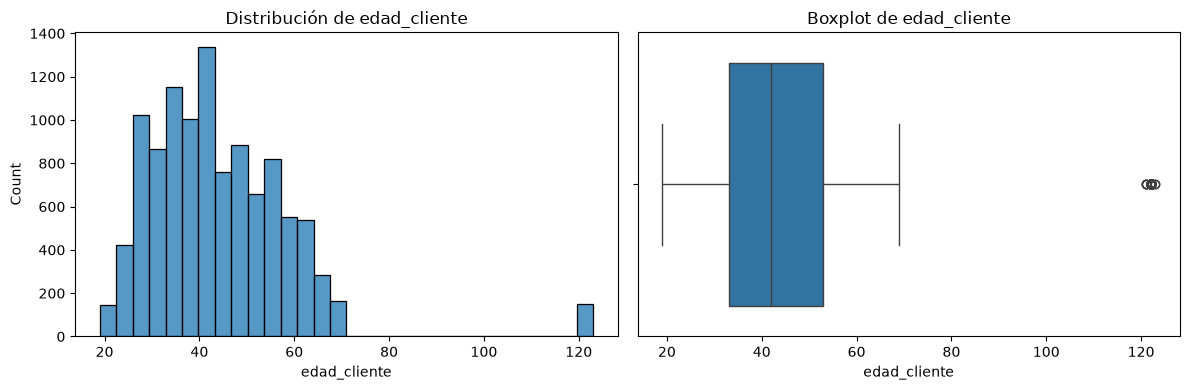

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["edad_cliente"], bins=30, ax=axes[0])
axes[0].set_title("Distribución de edad_cliente")

sns.boxplot(x=df["edad_cliente"], ax=axes[1])
axes[1].set_title("Boxplot de edad_cliente")

plt.tight_layout()
plt.show()

El histograma confirma que la mayoría de los clientes tiene entre 20 y 70 años, con una 
distribución razonable. Sin embargo, se observan un par de registros aislados cerca de los 
120-123 años, claramente separados del resto de la distribución — esto no es una cola natural 
de datos, sino valores atípicos (outliers) o errores de carga. El boxplot confirma esto 
marcándolos explícitamente como puntos fuera de los bigotes.

**Regla de validación propuesta:** un rango razonable para `edad_cliente` en este contexto 
sería entre 18 y 90 años; valores fuera de ese rango deberían marcarse para revisión o 
tratarse como error de dato.

**hora repliquemos esto para otra variable con problema: puntaje**

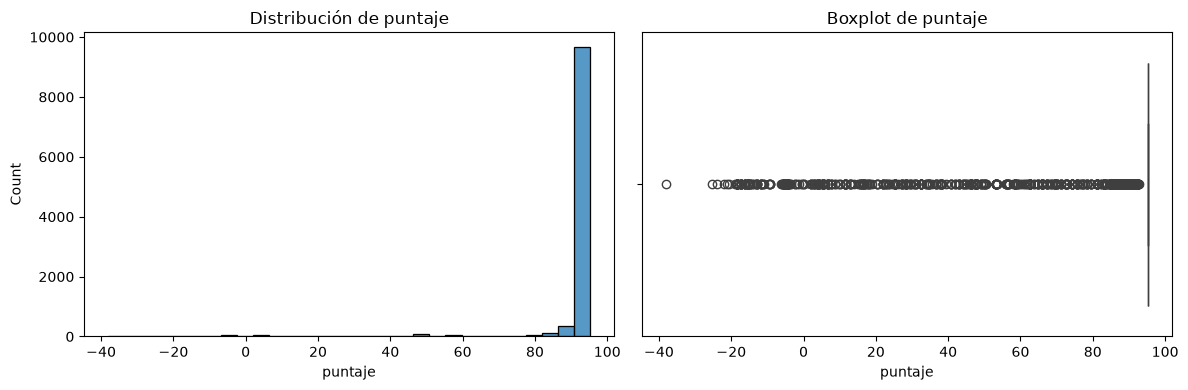

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["puntaje"], bins=30, ax=axes[0])
axes[0].set_title("Distribución de puntaje")

sns.boxplot(x=df["puntaje"], ax=axes[1])
axes[1].set_title("Boxplot de puntaje")

plt.tight_layout()
plt.show()

**investiguemos el valor repetido**

In [15]:
df["puntaje"].value_counts().head(10)

puntaje
95.227787    9407
89.979287      99
89.229500      82
91.997940      73
47.613894      59
84.730786      59
91.728786      56
92.228643      51
90.562453      46
91.410695      45
Name: count, dtype: int64

### Investigación de `puntaje`

Se detectó que el valor `95.227787` se repite 9407 veces (~87% del dataset) una coincidencia 
estadísticamente imposible para un puntaje calculado de forma individual. Se concluye que este 
es un valor de relleno (placeholder) usado por el sistema de origen para indicar "sin puntaje 
calculado", en vez de un valor real.

**Decisión:** se va a tratar `95.227787` como un valor faltante (nulo), para no distorsionar 
el análisis estadístico y el futuro modelo con un valor artificial repetido masivamente.

**reemplazarlo por nulo**

In [16]:
df.loc[df["puntaje"] == 95.227787, "puntaje"] = np.nan
df["puntaje"].isnull().sum()

np.int64(9407)

**Volvamos a graficar puntaje, ahora con los datos "limpios"**

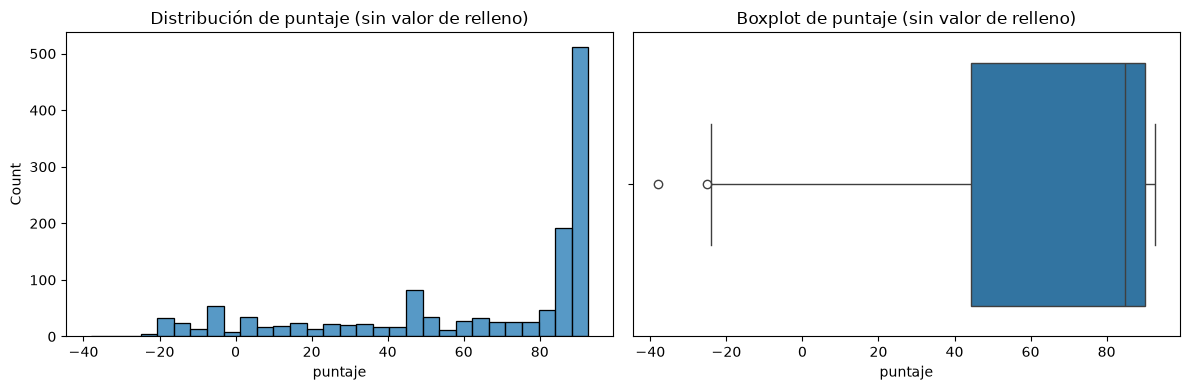

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["puntaje"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Distribución de puntaje (sin valor de relleno)")

sns.boxplot(x=df["puntaje"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de puntaje (sin valor de relleno)")

plt.tight_layout()
plt.show()

Al remover el valor de relleno (95.227787), la distribución real de `puntaje` se ve más 
dispersa, con concentración en el rango 80-95 pero también valores en todo el rango de 0 a 80. 

Sin embargo, persisten valores negativos (mínimo ~-38), los cuales no tienen sentido para un 
puntaje de crédito. Estos no parecen ser un valor de relleno (no se repiten de forma masiva 
como el caso anterior), por lo que probablemente sean errores de captura o cálculo puntuales. 

**Regla de validación propuesta:** un `puntaje` válido debería estar en un rango de 0 a 100; 
valores fuera de ese rango deberían marcarse para revisión.

**investiguemos puntaje_datacredito**

In [18]:
df["puntaje_datacredito"].value_counts().head(5)

puntaje_datacredito
0.0      145
802.0    102
783.0    102
791.0    100
801.0     98
Name: count, dtype: int64

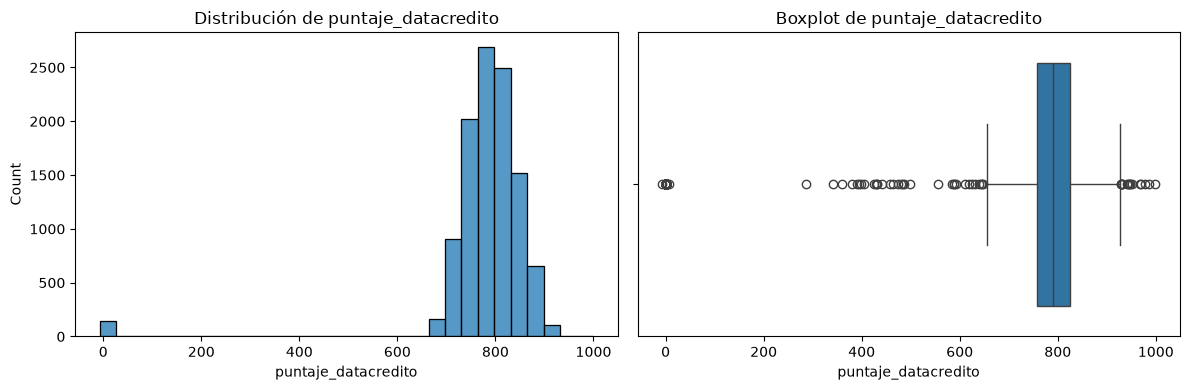

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["puntaje_datacredito"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Distribución de puntaje_datacredito")

sns.boxplot(x=df["puntaje_datacredito"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de puntaje_datacredito")

plt.tight_layout()
plt.show()

### Investigación de `puntaje_datacredito`

La distribución se concentra razonablemente entre 700-900, un rango típico para un puntaje 
crediticio (escala 150-950 aproximadamente). El valor `0` (145 casos) probablemente representa 
"sin puntaje calculado" más que un puntaje real. Los demás valores marcados como outliers por 
el boxplot están dispersos en un rango plausible (300-700) y no muestran evidencia de ser 
errores  se dejan como están, salvo el -7 detectado en el `describe()`, que sí está fuera de 
cualquier rango válido.

**Regla de validación propuesta:** rango válido 150-950; el valor `0` se tratará como "sin 
dato" (nulo).

**limpiar el 0 y el negativo**

In [20]:
df.loc[df["puntaje_datacredito"] <= 0, "puntaje_datacredito"] = np.nan
df["puntaje_datacredito"].isnull().sum()

np.int64(152)

**Sigamos con salario_cliente y total_otros_prestamos juntas**

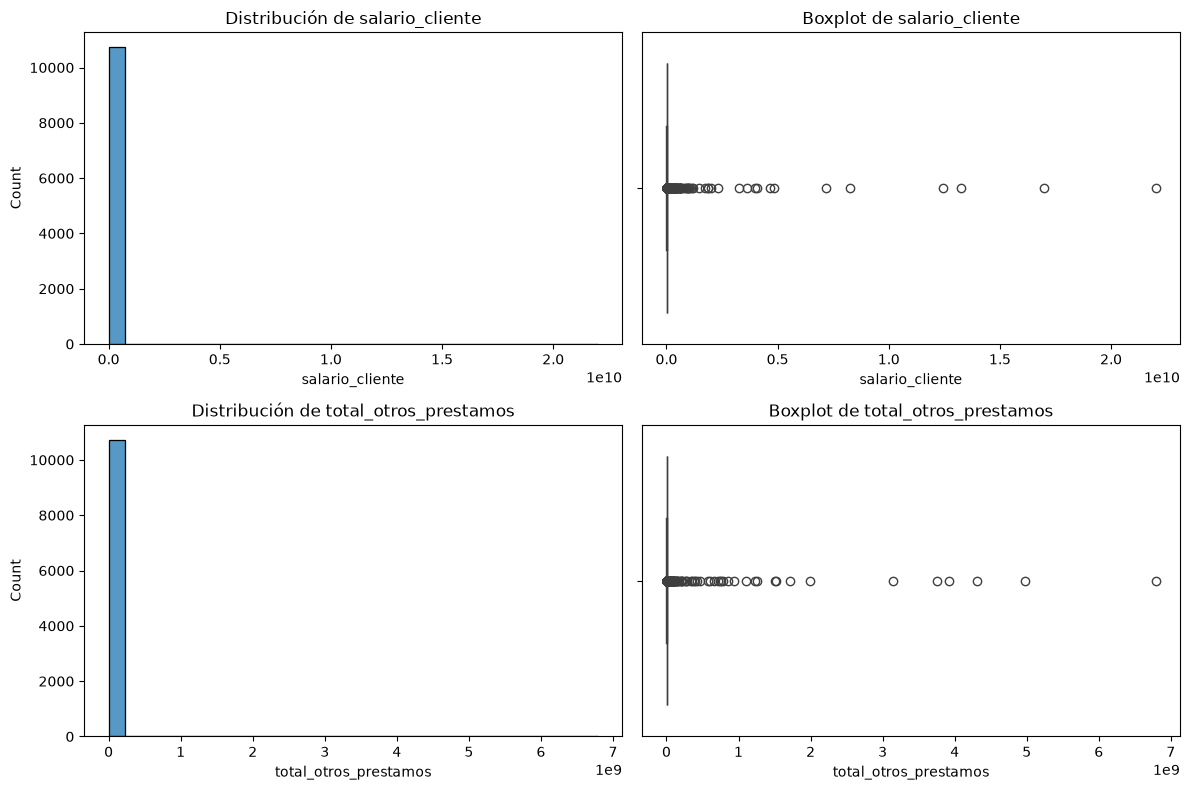

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["salario_cliente"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de salario_cliente")

sns.boxplot(x=df["salario_cliente"], ax=axes[0, 1])
axes[0, 1].set_title("Boxplot de salario_cliente")

sns.histplot(df["total_otros_prestamos"], bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Distribución de total_otros_prestamos")

sns.boxplot(x=df["total_otros_prestamos"], ax=axes[1, 1])
axes[1, 1].set_title("Boxplot de total_otros_prestamos")

plt.tight_layout()
plt.show()

**Investiguemos cuántos son y qué tan extremos**

In [22]:
print("Top 5 salarios más altos:")
print(df["salario_cliente"].sort_values(ascending=False).head())
print()
print("Top 5 total_otros_prestamos más altos:")
print(df["total_otros_prestamos"].sort_values(ascending=False).head())

Top 5 salarios más altos:
5735    22000000000
2866    16991100000
7014    13258352050
7043    12450806583
7041     8252584000
Name: salario_cliente, dtype: int64

Top 5 total_otros_prestamos más altos:
7043    6787675263
7070    4974345404
7014    4316463703
7110    3918433000
7058    3758729000
Name: total_otros_prestamos, dtype: int64


**Antes de decidir cómo tratarlos, veamos cuántos son realmente "extremos" versus solo "altos pero creíbles".**

In [23]:
print(df["salario_cliente"].describe())
print()
print("Cantidad de salarios mayores a 100 millones:", (df["salario_cliente"] > 100_000_000).sum())
print("Cantidad de salarios mayores a 1.000 millones:", (df["salario_cliente"] > 1_000_000_000).sum())

count    1.076300e+04
mean     1.721643e+07
std      3.554767e+08
min      0.000000e+00
25%      2.000000e+06
50%      3.000000e+06
75%      4.875808e+06
max      2.200000e+10
Name: salario_cliente, dtype: float64

Cantidad de salarios mayores a 100 millones: 74
Cantidad de salarios mayores a 1.000 millones: 22


### Investigación de `salario_cliente` y `total_otros_prestamos`

Ambas variables presentan outliers extremos: mientras la mediana de `salario_cliente` es de 
3.000.000, hay 74 registros (0.7%) que superan los 100.000.000, y 22 de esos superan incluso 
los 1.000.000.000    magnitudes no plausibles para un salario individual. Es un problema acotado 
(menos del 1% del dataset), consistente con errores de captura puntuales más que un problema 
sistemático.

**Regla de validación propuesta:** valores de `salario_cliente` superiores a 100.000.000 se 
tratan como error de dato y se convierten a nulo, para no distorsionar el análisis ni el 
futuro modelo. Se aplica el mismo criterio a `total_otros_prestamos`.

In [24]:
df.loc[df["salario_cliente"] > 100_000_000, "salario_cliente"] = np.nan
df.loc[df["total_otros_prestamos"] > 100_000_000, "total_otros_prestamos"] = np.nan

print("Nulos en salario_cliente:", df["salario_cliente"].isnull().sum())
print("Nulos en total_otros_prestamos:", df["total_otros_prestamos"].isnull().sum())

Nulos en salario_cliente: 74
Nulos en total_otros_prestamos: 44


**Volvamos a graficar, ahora con los outliers extremos removidos**

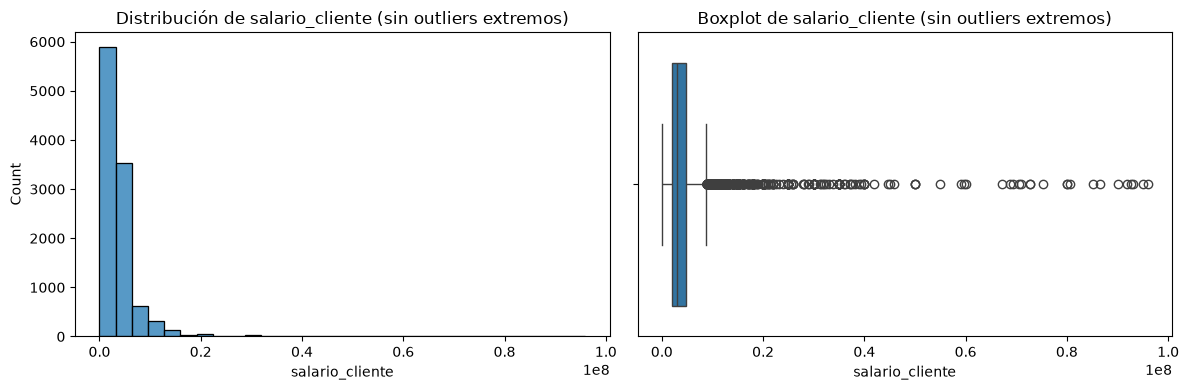

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["salario_cliente"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Distribución de salario_cliente (sin outliers extremos)")

sns.boxplot(x=df["salario_cliente"].dropna(), ax=axes[1])
axes[1].set_title("Boxplot de salario_cliente (sin outliers extremos)")

plt.tight_layout()
plt.show()

Al remover los outliers extremos (>100.000.000), la distribución de `salario_cliente` se ve 
mucho más interpretable: fuertemente concentrada en valores bajos, con una cola larga hacia la 
derecha  un patrón típico y esperable en variables de ingreso económico (la mayoría gana 
montos similares, y una minoría gana considerablemente más). Los outliers restantes que marca 
el boxplot ya no se consideran errores, sino variabilidad real de los datos, y no se van a 
seguir recortando.

**grilla rápida del resto de las numéricas**

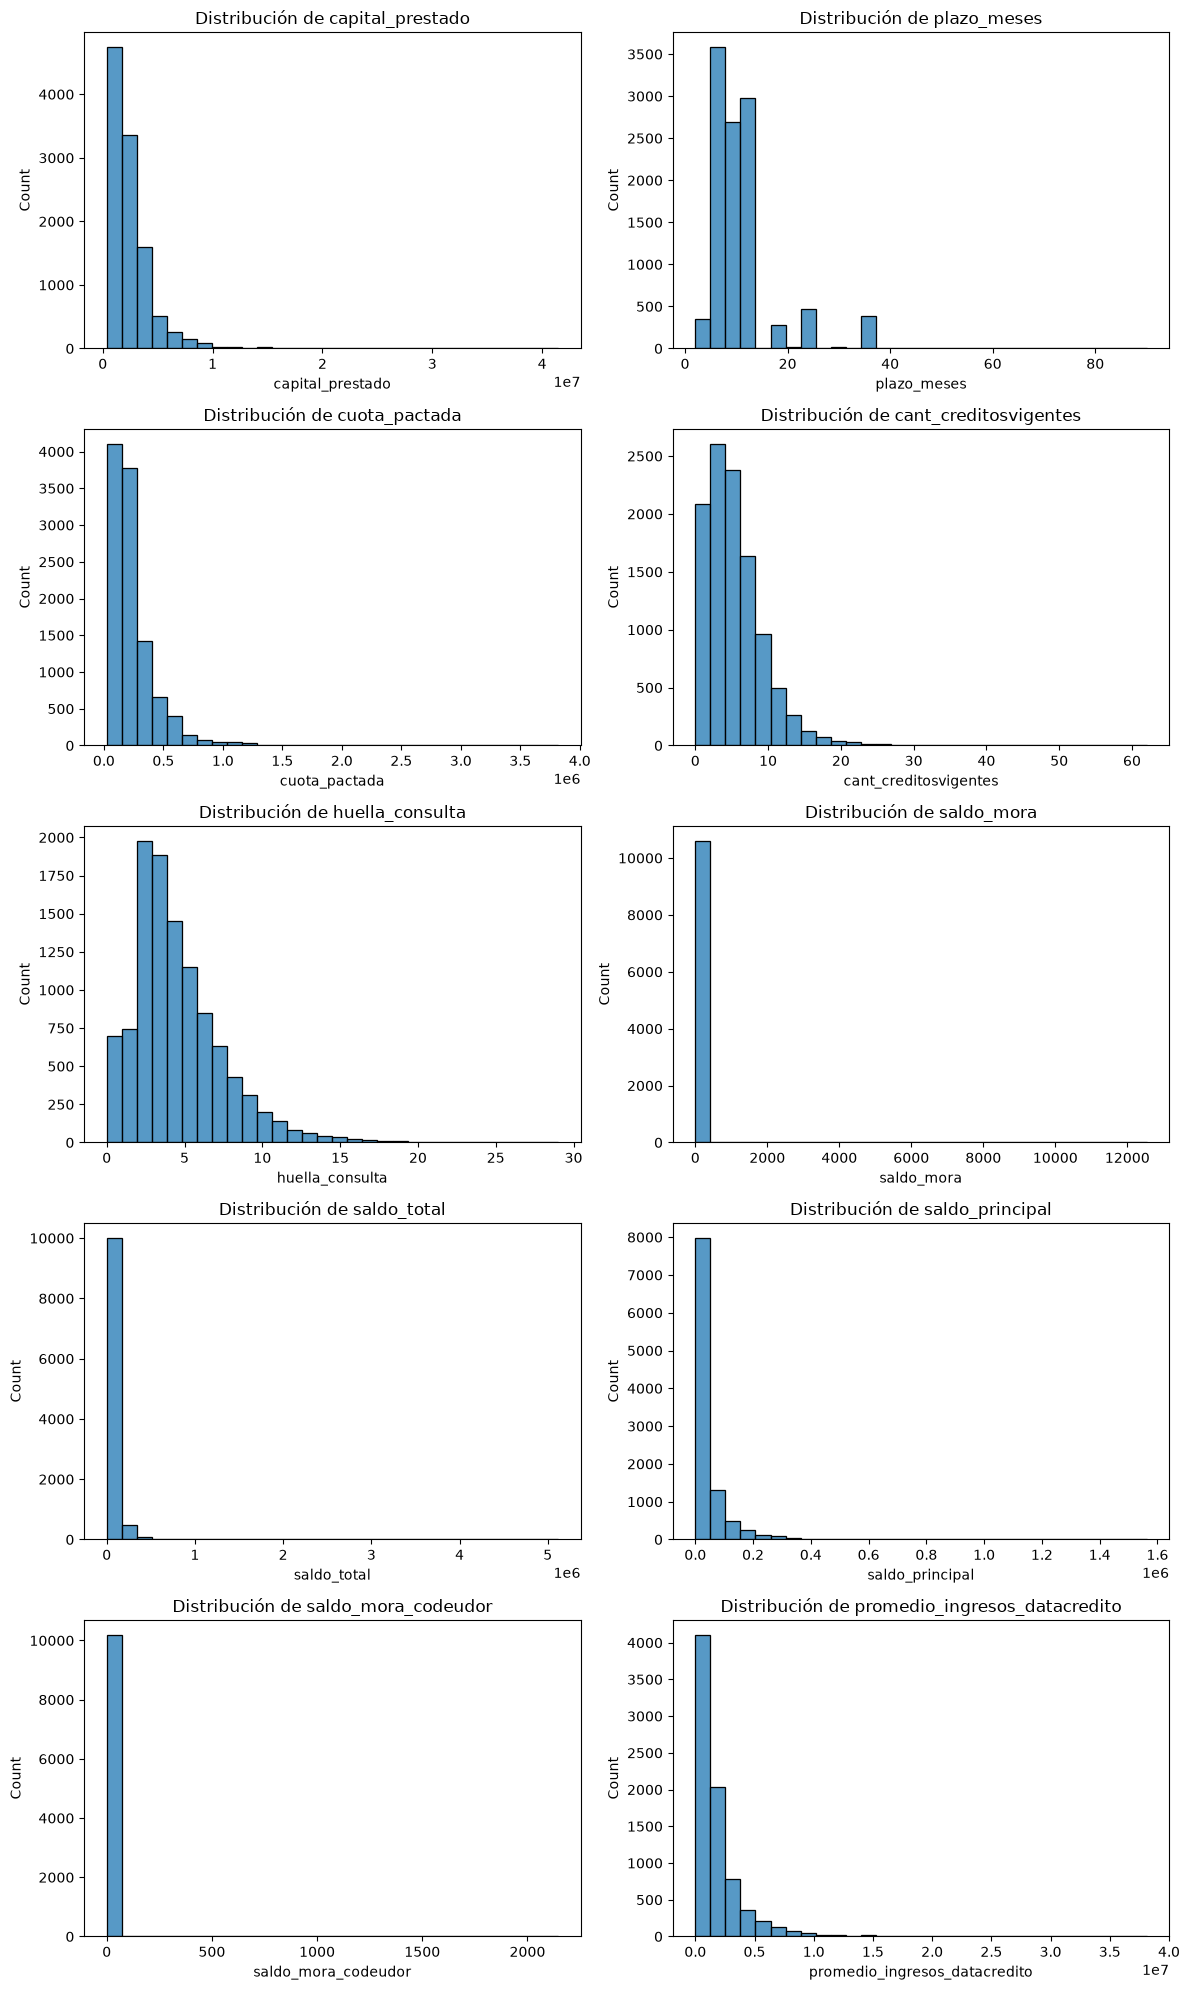

In [26]:
# Lista de las columnas numéricas que todavía no revisamos en detalle
numericas_restantes = ["capital_prestado", "plazo_meses", "cuota_pactada", "cant_creditosvigentes",
                        "huella_consulta", "saldo_mora", "saldo_total", "saldo_principal", 
                        "saldo_mora_codeudor", "promedio_ingresos_datacredito"]

# Creamos una grilla de 5 filas x 2 columnas = 10 espacios para gráficos (uno por variable)
# figsize=(12, 20) define el tamaño total de la figura (ancho, alto) en pulgadas
fig, axes = plt.subplots(5, 2, figsize=(12, 20))

# axes normalmente es una grilla 2D (5x2). flatten() la convierte en una lista simple
# de 10 elementos, para poder recorrerla con un solo índice (axes[0], axes[1], ...)
axes = axes.flatten()

# Recorremos la lista de columnas una por una
# enumerate() nos da, en cada vuelta, el índice (i: 0,1,2...) y el nombre de columna (col)
for i, col in enumerate(numericas_restantes):
    # dropna() excluye los nulos solo para graficar (no modifica el DataFrame real)
    # ax=axes[i] le dice a seaborn en qué "casillero" de la grilla dibujar este histograma
    sns.histplot(df[col].dropna(), bins=30, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")  # f-string: inserta el nombre de la columna en el título

# Ajusta automáticamente los espacios entre gráficos para que no se superpongan
plt.tight_layout()
# Muestra la figura completa
plt.show()

### Resto de variables numéricas

Las variables `capital_prestado`, `cuota_pactada`, `saldo_total`, `saldo_principal` y 
`promedio_ingresos_datacredito` muestran distribuciones sesgadas hacia la derecha (right-skewed), 
un patrón normal y esperado en variables monetarias   la mayoría de los valores son moderados, 
con una cola de valores más altos.

`saldo_mora` y `saldo_mora_codeudor` están concentradas en 0, consistente con que la mayoría 
de los clientes no tiene mora (recordar el desbalance de la variable objetivo: ~95% paga a 
tiempo).

`plazo_meses` muestra una franja aislada cerca de 80-90 meses   a diferencia de otros casos 
vistos antes, no hay evidencia de que sea un error (no se repite un valor exacto ni es un 
rango imposible); podría corresponder a un tipo de crédito específico. Se revisará más a 
fondo en el análisis bivariable, cruzándolo con `tipo_credito`.

No se identifican, en este bloque, valores que requieran limpieza adicional como en las 
variables anteriores.

**pasemos al análisis univariable de variables categóricas**

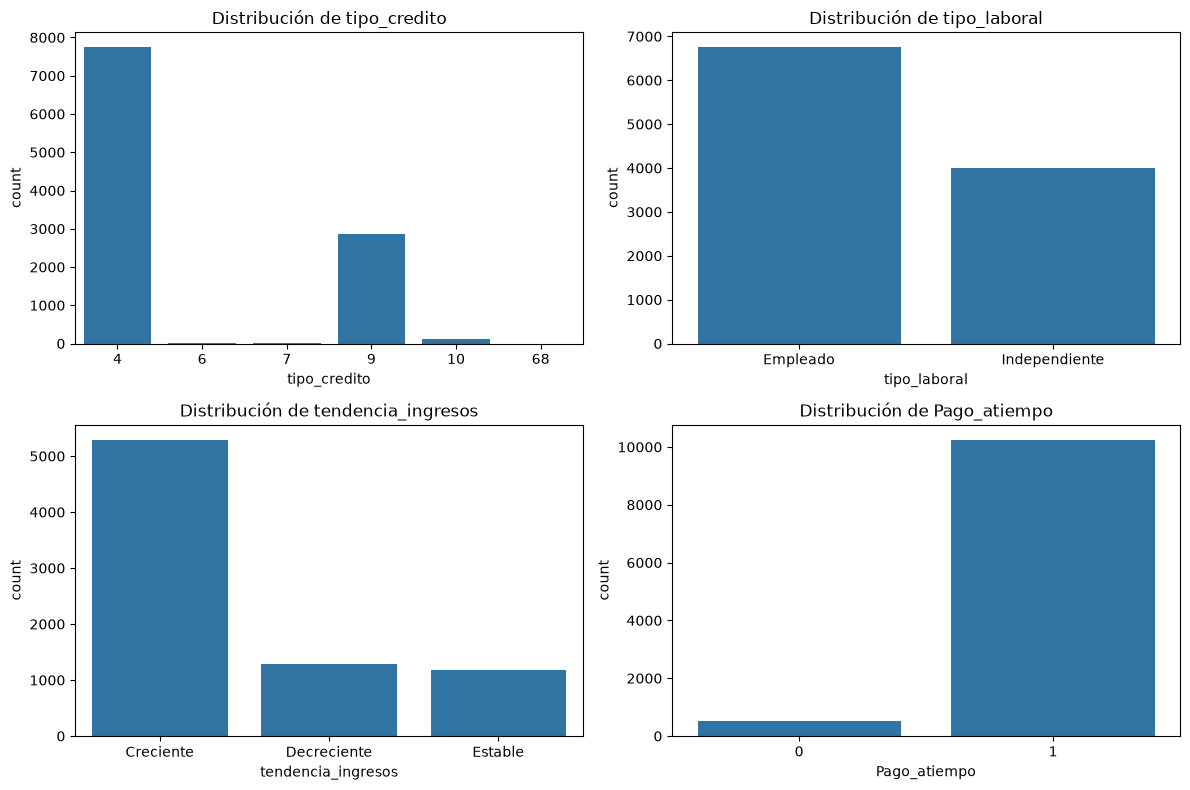

In [27]:
# Lista de las columnas categóricas que queremos analizar
# (incluimos Pago_atiempo también, aunque sea 0/1, porque conceptualmente es una categoría binaria)
categoricas = ["tipo_credito", "tipo_laboral", "tendencia_ingresos", "Pago_atiempo"]

# Grilla de 2 filas x 2 columnas, una por variable
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # la convertimos en lista simple, igual que antes

for i, col in enumerate(categoricas):
    # countplot cuenta automáticamente cuántas veces aparece cada categoría y las grafica como barras
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

**veamos los números exactos, no solo el gráfico**

In [28]:
# value_counts() con normalize=True nos da la proporción (en vez del conteo bruto)
# Esto es útil para ver porcentajes exactos, especialmente en Pago_atiempo

for col in categoricas:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(3) * 100)  # *100 para verlo como porcentaje
    print()

--- tipo_credito ---
tipo_credito
4     72.0
9     26.7
10     1.1
6      0.2
7      0.0
68     0.0
Name: proportion, dtype: float64

--- tipo_laboral ---
tipo_laboral
Empleado         62.8
Independiente    37.2
Name: proportion, dtype: float64

--- tendencia_ingresos ---
tendencia_ingresos
Creciente      68.1
Decreciente    16.6
Estable        15.3
Name: proportion, dtype: float64

--- Pago_atiempo ---
Pago_atiempo
1    95.3
0     4.7
Name: proportion, dtype: float64



### Interpretación del análisis univariable categórico

- **`tipo_credito`**: fuertemente concentrado en los códigos `4` (72%) y `9` (26.7%)   juntos 
  representan el 98.7% del dataset. Los códigos `6`, `7`, `10` y `68` son marginales.
- **`tipo_laboral`**: distribución razonable, 62.8% Empleado vs 37.2% Independiente.
- **`tendencia_ingresos`**: predominan los ingresos "Creciente" (68.1%), sobre "Decreciente" 
  (16.6%) y "Estable" (15.3%).
- **`Pago_atiempo` (variable objetivo)**: dataset fuertemente **desbalanceado** — 95.3% de los 
  clientes paga a tiempo, solo 4.7% no lo hace. 

**Implicación importante:** este desbalance de clases va a ser un factor clave a considerar 
en el Avance 2 (modelado). Un modelo entrenado sin ajustes podría lograr ~95% de exactitud 
simplemente prediciendo siempre "paga a tiempo" para todos los casos, sin aprender nada útil 
sobre los que no pagan   que es justamente el grupo que más interesa identificar desde el 
punto de vista del negocio. Se deberán considerar técnicas de balanceo (sub/sobremuestreo) o 
métricas de evaluación robustas al desbalance (F1, ROC-AUC, precision-recall) en lugar de 
solo exactitud (accuracy).

**análisis bivariable**

In [29]:
# Cruzamos cada variable categórica con Pago_atiempo
# crosstab crea una tabla que cuenta cuántos casos hay para cada combinación de valores
# normalize='index' hace que cada FILA sume 100% (así vemos el % que paga/no paga DENTRO de cada categoría)

for col in ["tipo_credito", "tipo_laboral", "tendencia_ingresos"]:
    print(f"--- {col} vs Pago_atiempo ---")
    tabla = pd.crosstab(df[col], df["Pago_atiempo"], normalize='index').round(3) * 100
    print(tabla)
    print()

--- tipo_credito vs Pago_atiempo ---
Pago_atiempo     0      1
tipo_credito             
4              4.7   95.3
6             42.9   57.1
7              0.0  100.0
9              4.7   95.3
10             2.6   97.4
68             0.0  100.0

--- tipo_laboral vs Pago_atiempo ---
Pago_atiempo     0     1
tipo_laboral            
Empleado       4.3  95.7
Independiente  5.5  94.5

--- tendencia_ingresos vs Pago_atiempo ---
Pago_atiempo          0     1
tendencia_ingresos           
Creciente           3.9  96.1
Decreciente         6.3  93.7
Estable             4.6  95.4



In [30]:
# Veamos los conteos absolutos (no porcentajes) para tipo_credito
# Esto nos permite chequear si las categorías minoritarias tienen suficientes casos como para ser confiables

conteo_absoluto = pd.crosstab(df["tipo_credito"], df["Pago_atiempo"])
print(conteo_absoluto)

Pago_atiempo    0     1
tipo_credito           
4             363  7384
6               9    12
7               0     2
9             136  2740
10              3   113
68              0     1


### Interpretación: tipo_credito vs Pago_atiempo

Si bien `tipo_credito = 6` muestra un 42.9% de no-pago (muy por encima del resto), este 
porcentaje se basa en apenas 21 casos totales — una muestra demasiado pequeña para ser una 
tendencia confiable. Lo mismo aplica a `tipo_credito = 7` (2 casos) y `68` (1 caso): no hay 
volumen suficiente para sacar conclusiones.

Las categorías con volumen representativo (`4` con 7747 casos, y `9` con 2876 casos) muestran 
un comportamiento de pago muy similar entre sí (~4.7% de no-pago en ambas), sin diferencias 
relevantes.

**Conclusión:** no se observa una relación fuerte y confiable entre `tipo_credito` y 
`Pago_atiempo`, dado que las categorías con diferencias notorias tienen muy pocos casos. 
Con `tendencia_ingresos`, en cambio, sí se observa una tendencia leve pero consistente 
(a peor tendencia de ingresos, mayor no-pago), con volumen suficiente en las 3 categorías 
para considerarla razonablemente confiable.

**bivariable de variables numéricas**

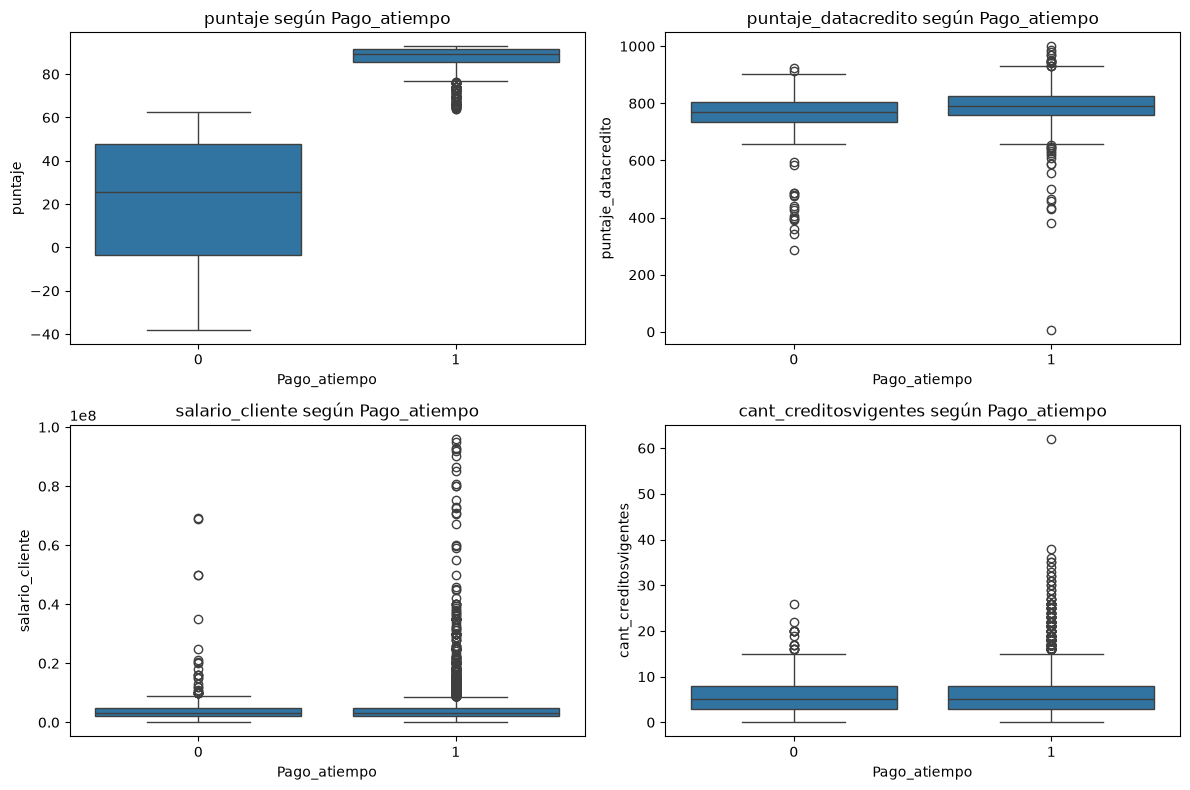

In [31]:
# Comparamos la distribución de algunas variables numéricas clave, separando por Pago_atiempo
# Esto nos permite ver si los que NO pagan a tiempo tienden a tener valores distintos en esas variables

variables_clave = ["puntaje", "puntaje_datacredito", "salario_cliente", "cant_creditosvigentes"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(variables_clave):
    # boxplot con x=Pago_atiempo separa la variable en 2 cajas: una para 0 (no pagó) y otra para 1 (sí pagó)
    sns.boxplot(x=df["Pago_atiempo"], y=df[col], ax=axes[i])
    axes[i].set_title(f"{col} según Pago_atiempo")

plt.tight_layout()
plt.show()

### Interpretación: variables numéricas vs Pago_atiempo

**`puntaje`** muestra una diferencia muy marcada entre grupos: los clientes que no pagaron a 
tiempo tienen una mediana de ~25, mientras que los que sí pagaron tienen una mediana de ~88, 
con las cajas prácticamente sin superposición. Esto sugiere que `puntaje` es, hasta ahora, 
la variable con mayor poder predictivo detectado en el EDA  resultado esperable, ya que es 
justamente un puntaje diseñado para estimar riesgo crediticio.

**`puntaje_datacredito`**, **`salario_cliente`** y **`cant_creditosvigentes`** muestran 
distribuciones muy similares entre ambos grupos (0 y 1), sin una diferencia visualmente 
relevante — no parecen ser, por sí solas, buenos predictores del comportamiento de pago.

**Un cruce más: plazo_meses vs tipo_credito (para resolver esa duda que quedó pendiente)**

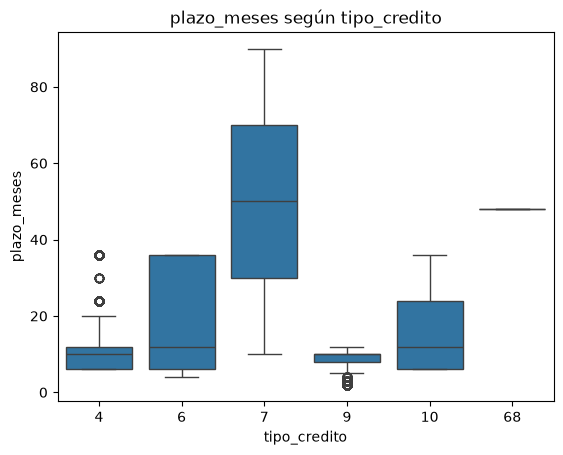

In [32]:
# Recordemos que plazo_meses tenía una franja aislada cerca de 80-90 meses
# Vamos a ver si eso se relaciona con un tipo_credito específico

sns.boxplot(x=df["tipo_credito"], y=df["plazo_meses"])
plt.title("plazo_meses según tipo_credito")
plt.show()

### Interpretación: plazo_meses vs tipo_credito

Se confirma que la franja aislada observada en el histograma de `plazo_meses` (cerca de 
80-90 meses) corresponde al `tipo_credito = 7`, el único tipo cuyo plazo se extiende más 
allá de los 40 meses (mediana de 50, llegando hasta 90). Esto sugiere que `tipo_credito = 7` 
representa una modalidad de crédito a largo plazo, distinta al resto. Sin embargo, como ya 
se señaló, esta categoría tiene solo 2 casos en el dataset, por lo que la conclusión debe 
tomarse como una hipótesis razonable más que como un patrón estadísticamente robusto.

No se considera un error de datos: es una franja aislada pero explicable por el tipo de 
crédito, a diferencia de los outliers sin explicación lógica detectados en otras variables.

## 3. Análisis multivariable

Analizamos las relaciones entre todas las variables numéricas simultáneamente, mediante 
una matriz de correlación, para identificar qué variables se relacionan más fuertemente 
entre sí y, en particular, con la variable objetivo `Pago_atiempo`.

**Análisis multivariable — la matriz de correlación**

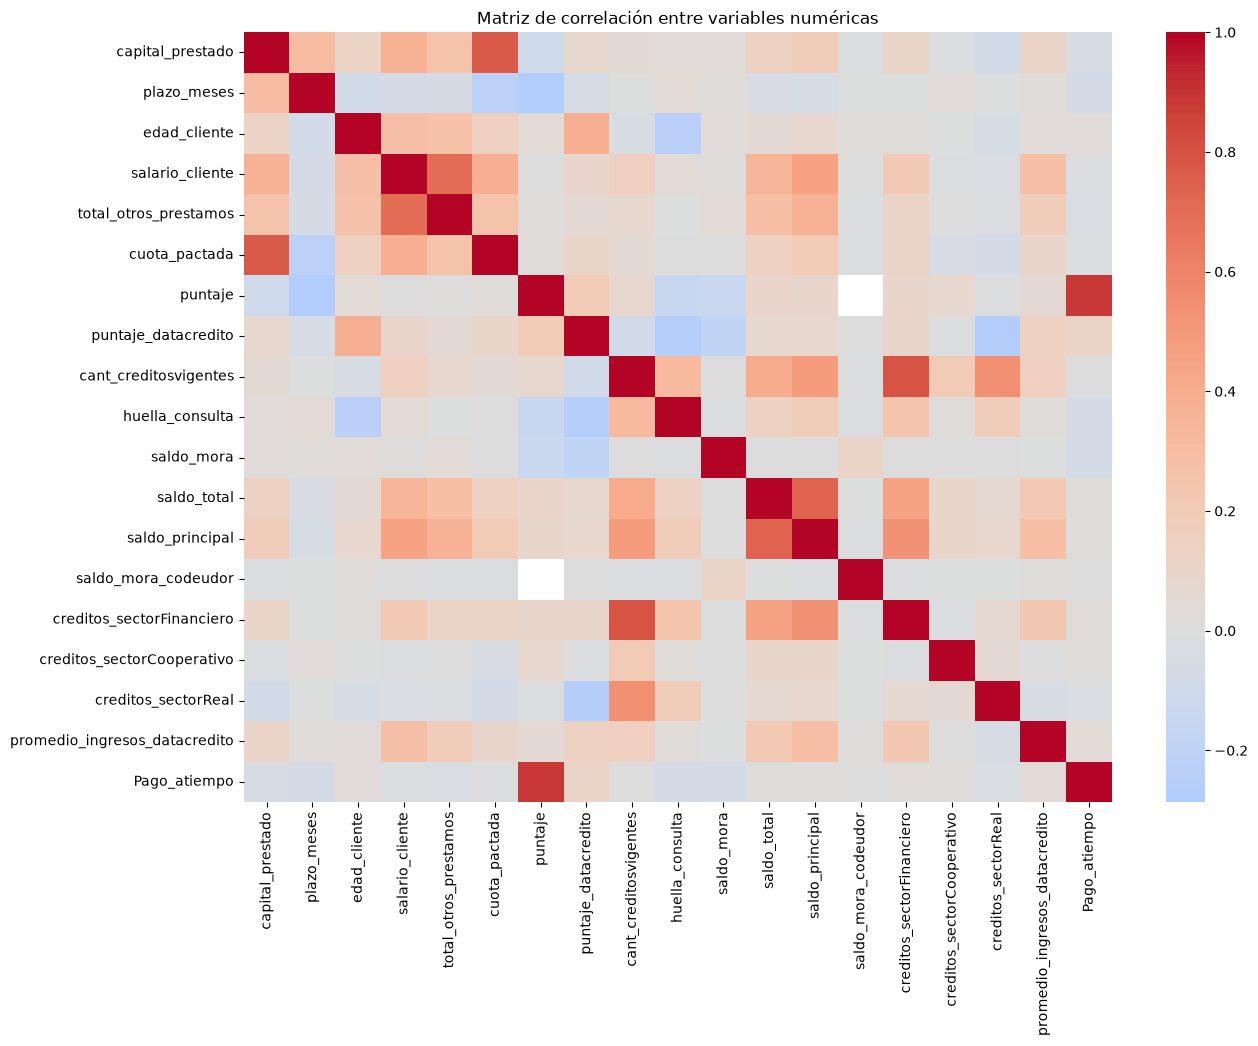

In [33]:
# Seleccionamos solo las columnas numéricas (corr() no funciona con texto/categorías)
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns

# corr() calcula el coeficiente de correlación de Pearson entre cada par de columnas
# Va de -1 (relación inversa perfecta) a +1 (relación directa perfecta), 0 = sin relación lineal
matriz_correlacion = df[columnas_numericas].corr()

# Graficamos la matriz como un "mapa de calor" (heatmap): más fácil de leer que una tabla de números
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacion, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

In [34]:
# De la matriz completa, extraemos solo la columna de Pago_atiempo
# sort_values ordena de mayor a menor correlación (positiva o negativa)
correlacion_target = matriz_correlacion["Pago_atiempo"].sort_values(ascending=False)
print(correlacion_target)

Pago_atiempo                     1.000000
puntaje                          0.879987
puntaje_datacredito              0.119669
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
saldo_principal                  0.011473
cant_creditosvigentes            0.008829
saldo_mora_codeudor              0.002631
salario_cliente                 -0.011296
cuota_pactada                   -0.011814
total_otros_prestamos           -0.020991
creditos_sectorReal             -0.023306
capital_prestado                -0.040624
plazo_meses                     -0.063105
saldo_mora                      -0.073458
huella_consulta                 -0.073737
Name: Pago_atiempo, dtype: float64


### Interpretación de la matriz de correlación

El hallazgo más importante del análisis multivariable es la altísima correlación entre 
`puntaje` y `Pago_atiempo` (**0.88**) — muy por encima de cualquier otra variable. Esto 
confirma, con un número concreto, lo que ya habíamos observado visualmente en el análisis 
bivariable: `puntaje` es, por lejos, el predictor más fuerte disponible en este dataset.

El resto de las variables numéricas muestran correlaciones muy débiles con `Pago_atiempo` 
(todas por debajo de 0.12 en valor absoluto), lo que sugiere que, por sí solas, no tienen 
mucho poder predictivo lineal. Esto no significa que sean inútiles para el modelo — podrían 
aportar valor en combinación con otras variables, o mediante relaciones no lineales que un 
coeficiente de correlación (que solo mide relaciones lineales) no captura.

**Conclusión clave para el Avance 2 (modelado):** `puntaje` debe ser tratado como la variable 
más relevante del dataset. Dado que también tiene ~9407 valores nulos (los que eran el valor 
de relleno que limpiamos), la estrategia de imputación que se use para esos nulos va a tener 
un impacto directo e importante en el desempeño del futuro modelo.

## 4. Conclusiones y próximos pasos

### Reglas de validación de datos identificadas
- `edad_cliente`: rango válido 18-90 años.
- `puntaje`: rango válido 0-100; el valor `95.227787` (relleno) y valores negativos se 
  tratan como nulo.
- `puntaje_datacredito`: rango válido 150-950; el valor `0` y negativos se tratan como nulo.
- `salario_cliente` y `total_otros_prestamos`: valores superiores a 100.000.000 se tratan 
  como error y se convierten a nulo.
- `tendencia_ingresos`: solo son válidas las categorías Estable/Creciente/Decreciente; 
  cualquier otro valor (numérico) se trata como nulo.

### Atributos derivados sugeridos para el Avance 2
- De `fecha_prestamo`: extraer `mes_prestamo` y/o `año_prestamo`, dado que la fecha completa 
  (con hora) tiene demasiada cardinalidad para ser útil tal cual.

### Variable más relevante detectada
`puntaje` muestra una correlación muy fuerte (0.88) con la variable objetivo `Pago_atiempo`, 
y una diferencia muy marcada en su distribución entre clientes que pagan y no pagan a tiempo. 
Será clave definir una buena estrategia de imputación para sus valores nulos (~87% del dataset, 
originados en un valor de relleno que fue limpiado durante este EDA).

### Desbalance de clases
El dataset está fuertemente desbalanceado (95.3% paga a tiempo vs 4.7% no paga). Esto deberá 
considerarse en el Avance 2 mediante técnicas de balanceo y/o métricas de evaluación robustas 
al desbalance (F1, ROC-AUC, precision-recall), en lugar de exactitud (accuracy) simple.

### Transformaciones de tipo de dato realizadas
- `fecha_prestamo`: convertida de texto a `datetime`.
- `tipo_credito`, `tipo_laboral`, `tendencia_ingresos`: convertidas a `category`.